# Benchmark Results

## Initialization

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import time

dp_root = "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks"
dp = os.path.join(dp_root, "data/virtual_screening")
dict_dataset_n = dict()

for dataset in os.listdir(dp):
    fp_active = os.path.join(dp, dataset, "unidock1_protein", "actives_prepared_torsion_tree.sdf")
    out = os.popen(f"grep '$$$$' {fp_active} | wc -l")    
    n_active = int(out.readline().strip())

    fp_inactive = os.path.join(dp, dataset, "unidock1_protein", "inactives_prepared_torsion_tree.sdf")
    out = os.popen(f"grep '$$$$' {fp_inactive} | wc -l")    
    n_inactive = int(out.readline().strip())
    dict_dataset_n[dataset] = {"n_active": n_active, "n_inactive": n_inactive, "n_total": n_active + n_inactive}
    print("{:8}: n_active= {:4}, n_inactive= {:4}".format(dataset, n_active, n_inactive))


def read_rounds(dp, keys:list|str, list_dataset:list|str):
    list_df = []
    for repeat in os.listdir(dp):
        fp_metrics = os.path.join(dp, repeat, "metrics.csv")
        if not os.path.exists(fp_metrics):
            continue
        df = pd.read_csv(fp_metrics)
        list_df.append(df)
    df = pd.concat(list_df)
    res = [list_dataset]
    for k in keys:
        res.append([np.mean(df[df["dataset"] == dataset][k].values) for dataset in list_dataset])
    return res

def read_round(dp, keys:list|str, list_dataset:list|str):
    fp_metrics = os.path.join(dp, "metrics.csv")
    df = pd.read_csv(fp_metrics)

    res = [list_dataset]
    for k in keys:
        res.append([np.mean(df[df["dataset"] == dataset][k].values) for dataset in list_dataset])
    return res

def auto_figsize(n_dataset, n_method, n_subplots=2):
    """
    Wide-layout figure size for paper-style benchmark plots.
    Emphasizes horizontal expansion and compressed vertical space.
    """

    # Horizontal size: strongly driven by datasets and subplots
    width_per_dataset = 2.6
    method_bonus = 0.5
    subplot_bonus = 1.8

    width = (
        width_per_dataset * n_dataset
        + method_bonus * max(0, n_method - 1)
        + subplot_bonus * (n_subplots - 1)
    )

    # Vertical size: compressed and weakly dependent on method count
    base_height = 4
    method_height = 0.15 * max(0, n_method - 2)

    height = base_height + method_height

    return (width, height)



def auto_font(n_dataset, n_method):
    """
    Paper-oriented automatic font scaling.
    Designed to stay compact and avoid oversized titles/labels.
    """

    # Gentle scaling only when the figure becomes very dense
    scale_dataset = min(1.0, 3.0 / max(1, n_dataset))
    scale_method = min(1.0, 4.0 / max(1, n_method))
    scale = 0.9 * scale_dataset * scale_method

    return {
        "title": int(14 * scale + 1),     # was ~18 before
        "label": int(12 * scale + 1),     # x/y labels
        "tick": int(10 * scale + 1),
        "legend": int(10 * scale + 1),
        "bar_text": int(9 * scale + 1),
    }



def plot_bar(
    list_data,
    xnames,
    list_label=None,
    xlabel=None,
    ylabel=None,
    text_perc=True,
    text_nf=None,
    ax=None,
    show_legend=True,
    y_hi=None,
):
    """
    Generic grouped bar plot with automatic layout adaptation.
    """

    colors = [
        "#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B3",
        "#937860", "#84B1CD", "#6A915D", "#D77FB4", "#7F7F7F",
    ]

    if ax is None:
        ax = plt.gca()

    n_method = len(list_data)
    n_dataset = len(xnames)

    if list_label is None:
        list_label = [None] * n_method

    # Grouped bar geometry
    group_width = 0.8
    bar_width = group_width / n_method
    list_x = np.arange(n_dataset)
    offset = (n_method - 1) / 2

    # Plot bars
    for i, data in enumerate(list_data):
        bars = ax.bar(
            list_x + (i - offset) * bar_width,
            data,
            bar_width,
            label=list_label[i],
            color=colors[i % len(colors)],
            alpha=0.9,
            linewidth=0.5,
        )

        # Bar annotations
        for bar in bars:
            val = bar.get_height()
            if text_nf is not None:
                fmt = f"{{:.{int(text_nf)}f}}"
            else:
                fmt = "{:.1f}"

            if text_perc:
                text = fmt.format(val * 100) + "%"
            else:
                text = fmt.format(val)

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                text,
                ha="center",
                va="bottom",
                fontsize=FONT["bar_text"],
            )

    # Axes formatting
    ax.set_xticks(list_x)
    ax.set_xticklabels(xnames, fontsize=FONT["tick"])
    ax.tick_params(axis="y", labelsize=FONT["tick"])

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=FONT["label"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=FONT["label"])

    # Legend
    if show_legend and any(list_label):
        ax.legend(
            fontsize=FONT["legend"],
            frameon=False,
            loc="best",
        )

    # Grid styling
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    
    # Set y-axis upper limit to the maximum tick value
    y_ticks = ax.get_yticks()
    if len(y_ticks) > 0:
        y_max_tick = y_ticks[-1]
        y_min = ax.get_ylim()[0]
        ax.set_ylim(bottom=y_min, top=y_max_tick)
    if y_hi is not None:
        ax.set_ylim(top=y_hi)


def plot_bar_hit_rates(list_data, xlabels, list_label=None, ax=None, show_legend=True):
    plot_bar(
        list_data,
        xlabels,
        list_label,
        xlabel="Dataset",
        ylabel="Hit Rate (RMSD < 2.0)",
        text_nf=0,
        ax=ax,
        show_legend=show_legend,
        y_hi=1.0,
    )


def plot_bar_cost(list_data, xlabels, list_label=None, ax=None, show_legend=True):
    plot_bar(
        list_data,
        xlabels,
        list_label,
        xlabel="Dataset",
        ylabel="Average Time Cost (s)",
        text_perc=False,
        ax=ax,
        show_legend=show_legend,
    )


def plot_benchmark(
    result_dirs,
    xlabels=None,
    data_keys=None,
    prefixes=None,
    mode="docking",  # "docking" or "screening"
    auto_size = True,
    figfile=None,
):
    """
    Unified benchmark plotting for docking or screening.

    Features:
    - Adaptive subplots
    - Adaptive figure size and fonts
    - Optional water detection for docking
    - Legend placed outside last subplot
    """
    # ------------------------------
    # Set default keys/labels per mode
    # ------------------------------
    
    if mode == "docking":
        if xlabels is None:
            xlabels = ["Astex", "CASF2016", "PoseBuster"]
        if data_keys is None:
            data_keys = ["hit_rate_rmsd2.0", "avr_time(s)"]
        ylabel_list = ["Hit Rate (RMSD < 2.0)", "Average Time Cost (s)"]
        text_perc = [True, False]
        text_nf = [0, None]
        title_prefix="Benchmark Result of Molecular Docking"

    elif mode == "screening":
        if xlabels is None:
            xlabels = ["D4", "NSP3", "PPARG", "sigma2"] #
        if data_keys is None:
            data_keys = ["Enrichment (5%)", "Cost (s/ligand)"] #, "Hit (5%)"
        ylabel_list = ["Enrichment (5%)", "Average Time Cost (s)"] # , "Hit (top 5%)"
        text_perc = [False, False] # , False
        text_nf = [2, 2] # , 0
        title_prefix="Benchmark Result of Virtual Screening"
    else:
        raise ValueError(f"Unknown mode: {mode}")

    n_subplots = len(data_keys)
    data_list = [[] for _ in range(n_subplots)]
    labels = []

    # ------------------------------
    # Read data
    # ------------------------------
    for i, dp in enumerate(result_dirs):
        res = read_rounds(dp, data_keys, xlabels)
        for j in range(n_subplots):
            data_list[j].append(res[j + 1])

        basename = os.path.basename(dp)
        version = basename.split("_")[1] if "_" in basename else basename

        if prefixes is None:
            if basename.startswith("res1"):
                prefix = "ud1"
            elif basename.startswith("res2"):
                prefix = "ud2"
            else:
                prefix = basename
        else:
            prefix = prefixes[i]

        labels.append(f"{prefix}_{version}")

    n_dataset = len(xlabels)
    n_method = len(data_list[0])

    # ------------------------------
    # Fonts and figure size
    # ------------------------------
    global FONT
    if auto_size:
        FONT = auto_font(n_dataset, n_method)
        figsize = auto_figsize(n_dataset, n_method, n_subplots=n_subplots)
    else:
        FONT = {"title": 14, "label": 12, "tick": 10, "legend": 10, "bar_text": 9}
        figsize = (11, 4)

    fig = plt.figure(figsize=figsize, dpi=300)

    # ------------------------------
    # Subplot layout (统一 GridSpec)
    # ------------------------------
    gs = fig.add_gridspec(1, n_subplots, wspace=0.25)
    axes = [fig.add_subplot(gs[0, i]) for i in range(n_subplots)]

    for i in range(n_subplots):
        if mode == "docking":
            if i == 0:
                plot_bar_hit_rates(data_list[i], xlabels, labels, ax=axes[i], show_legend=False)
            else:
                plot_bar_cost(data_list[i], xlabels, labels, ax=axes[i], show_legend=False)
        else:
            plot_bar(
                data_list[i],
                xlabels,
                list_label=labels,
                ax=axes[i],
                xlabel="Dataset",
                ylabel=ylabel_list[i],
                text_perc=text_perc[i],
                text_nf=text_nf[i],
                show_legend=False
            )

    # ------------------------------
    # Legend outside last subplot
    # ------------------------------
    handles, _ = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        fontsize=FONT["legend"],
        frameon=False
    )

    # ------------------------------
    # Auto-detect water status for docking
    # ------------------------------
    str_water = ""
    if mode == "docking":
        last_dir = result_dirs[-1] if isinstance(result_dirs[-1], str) else result_dirs[-1][0]
        try:
            fp_yaml = os.path.join(last_dir, "benchmark.yaml")
            if os.path.exists(fp_yaml):
                with open(fp_yaml, "r") as f:
                    cfg = yaml.safe_load(f)
                nowater = cfg.get("benchmark", {}).get("nowater", False)
                str_water = "Without Water" if nowater else "With Water"
            elif "nowater" in os.path.basename(last_dir):
                str_water = "Without Water"
            else:
                str_water = "With Water"
        except Exception as e:
            print(f"Warning: Could not detect water status: {e}")

    # ------------------------------
    # Title
    # ------------------------------
    title = title_prefix
    if str_water:
        title += f" ({str_water})"
    title += f"\nUpdate: {time.strftime('%Y-%m-%d', time.localtime())}"
    fig.suptitle(title, fontsize=FONT["title"], y=1)

    if figfile is not None:
        fig.savefig(figfile, dpi=300)
    plt.tight_layout()
    return fig

## Docking Test

/tmp/ipykernel_801121/391179065.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


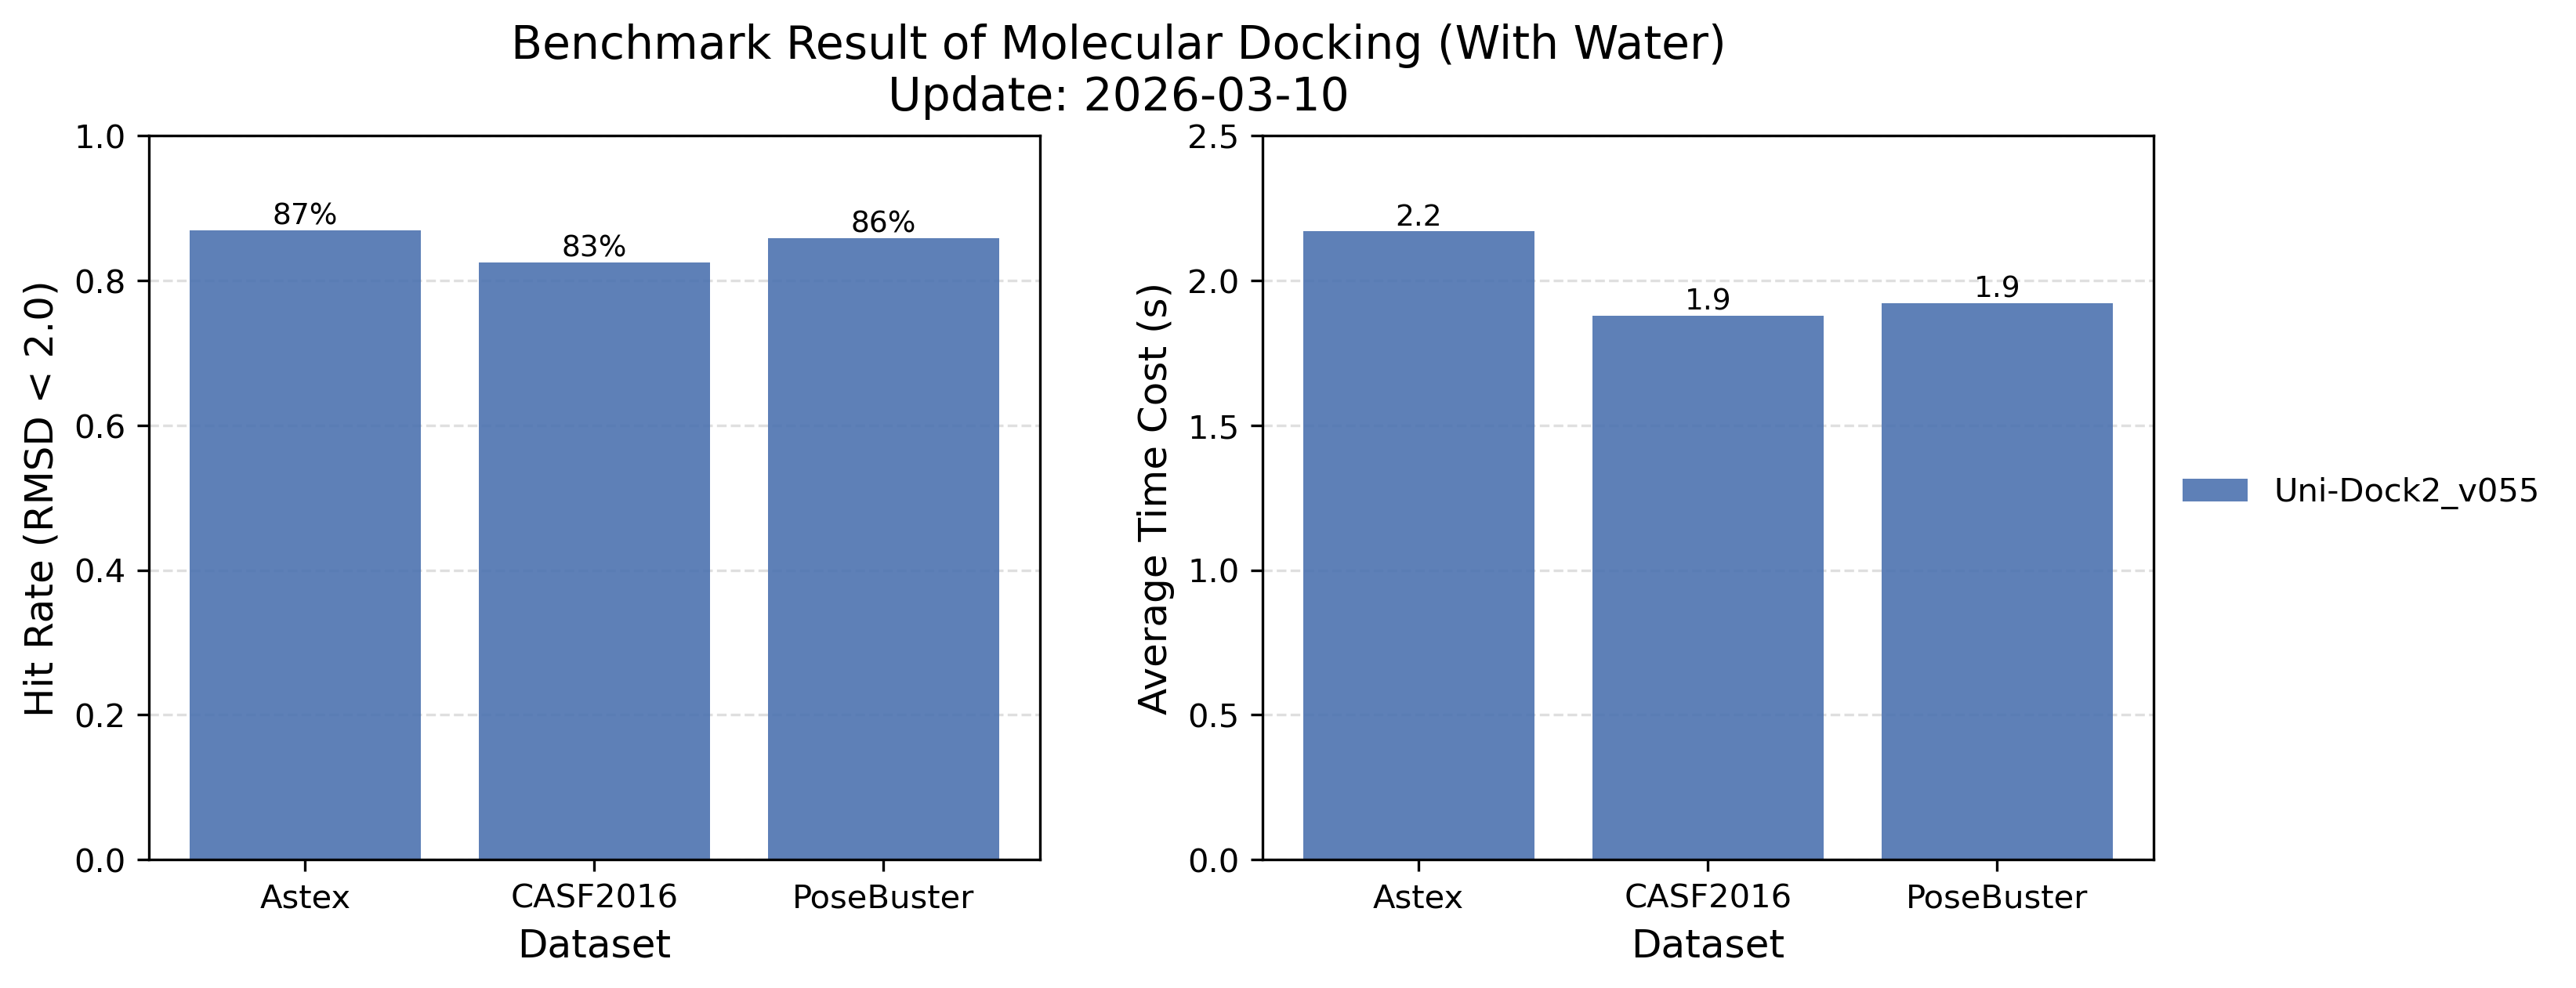

In [3]:
fig = plot_benchmark(
    [
        # "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res1_v1.1.3_dock", 
    "/data/liucc/project/Uni-Dock-Benchmarks/results/ud2_v055_dock",
        # "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_0.5.2_dock_mc20",
        # "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_0.5.2_dock_mc20_ex1024",

    ],
    
    prefixes=["Uni-Dock2"],
    auto_size=False,
    figfile="docking_with_water.png"
    )

In [ ]:
fig = plot_benchmark(
    ["/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res1_v1.1.3_dock_nowater", 
        "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_0.5.2_dock_nowater"],
    
    prefixes=["Uni-Dock1", "Uni-Dock2"],
    auto_size=False,
    figfile="docking_without_water.png"
    )

## Screening Test

In [ ]:
fig = plot_benchmark(
    ["/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res1_v1.1.3_screen", 
    "/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_0.5.2_screen",
    ],
    
    prefixes=["Uni-Dock1", "Uni-Dock2"],
    mode="screening",
    auto_size=False,
    figfile="screening.png"
    )

# Analyze

## 比较多轮次结果，具体有问题的pdbid是哪些

In [ ]:
import os
import pandas as pd
from utils.myio import *

def merge_df(list_df: list|pd.DataFrame):
    df_2 = pd.concat(list_df)
    df_2_merged = df_2.pivot_table(index=["dataset", "pdbid"], 
                                columns=["version", "round"], 
                                values=["Top1Success"], 
                                aggfunc='first')

    # 重命名列以包含 version 和 round 的后缀
    df_2_merged.columns = [f"{metric}_{version}_{round}" for metric, version, round in df_2_merged.columns]
    df_2_merged.reset_index(inplace=True)
    return df_2_merged

def read_bench_merge_res(dp_res:str, version="v1"):
    list_df = []
    for r, name in enumerate(sorted(os.listdir(dp_res))):
        fp_metrics = os.path.join(dp_res, name, "res.csv")
        if not os.path.exists(fp_metrics):
            continue
        df = pd.read_csv(fp_metrics)
        df = df[["dataset", "pdbid", "Top1Success"]]
        df["version"] = version
        df["round"] = r
        list_df.append(df)
        
    df_1 = merge_df(list_df)
    return df_1

def check_1good_2bad(df_1:pd.DataFrame, df_2:pd.DataFrame):
    top1success_columns = [i for i in df_1.columns if i.startswith("Top1Success")]
    df_1_true = df_1[df_1[top1success_columns].all(axis=1)]
    top1success_columns = [i for i in df_2.columns if i.startswith("Top1Success")]
    df_2_false = df_2[~df_2[top1success_columns].any(axis=1)]
    pd_res = pd.merge(df_1_true, df_2_false, on=["dataset", "pdbid"])
    print(len(pd_res)) # 7f
    # add a column of ntor
    # 添加 ntor 列：根据 dataset 和 pdbid 从 dict_ntor 中提取值
    # pd_res["ntor"] = pd_res.apply(
    #     lambda row: dict_ntor[row["dataset"]].get(row["pdbid"], None), 
    #     axis=1
    # )
    return pd_res


In [ ]:
df1 = read_bench_merge_res("res2_0.4.2b_nowater", version="0.4.2b")
df2 = read_bench_merge_res("res2_0.4.2b_nowater_torlib", version="0.4.2b_torlib")
check_1good_2bad(df1, df2)

In [ ]:
df1 = pd.read_csv("/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_251217-oldgrad_dock/res2_251217-oldgrad_dock_1/Astex/res.csv")
df2 = pd.read_csv("/data/liucc/project/ud2_benchmark/Uni-Dock-Benchmarks/res2_251209_dock/res2_251209_dock_1/res.csv")
check_1good_2bad(df2, df1)

In [ ]:
df1 = read_bench_merge_res("res2_0.4.2b", version="0.4.2b")
df2 = read_bench_merge_res("res2_0.4.2b_torlib", version="0.4.2b_torlib")
check_1good_2bad(df1, df2)

In [ ]:
check_1good_2bad(df2, df1)

In [ ]:
dp = "res2_0.4.2a"
# check the failed cases
import os
import pandas as pd
list_df = []
for dn in os.listdir(dp):
    round = int(dn.split("_")[-1])
    dp_round = os.path.join(dp, dn)
    fp_res = os.path.join(dp_round, "res.csv")
    df = pd.read_csv(fp_res)
    df_tmp = df[df["Top1Success"] == False][["dataset", "pdbid"]]
    list_df.append(df_tmp)

# find the cased failing for all rounds, as a df_fail
df_all = pd.merge(list_df[0], list_df[1], on=["dataset", "pdbid"])
df_all = pd.merge(df_all, list_df[2], on=["dataset", "pdbid"])
df_all[df_all["dataset"] == "Astex"]

## 抽取结构

In [ ]:
from utils.myio import *
import shutil
import os


def prepare_input_ud2(dp_ud2, dataset, pdbid, dp_ud1=[]):
    if isinstance(dp_ud2, list):
        dp_list = dp_ud2
        dp_ud2 = dp_list[0]
    else:
        dp_list = [dp_ud2]

    dp_root = os.path.dirname(dp_ud2)    
    while(not ((os.path.basename(dp_root)).startswith("bench"))):
        dp_root = os.path.dirname(dp_root)
    
    # dp_data = os.path.join(dp_root, "data/molecular_docking", dataset, pdbid)
    dp_res = os.path.join(dp_root, f"{dataset}_{pdbid}")    
    os.makedirs(dp_res, exist_ok=True)
    for i, d in enumerate(dp_list):
        fp_sdf_res = os.path.join(d, dataset, "free/0", pdbid, "ud2_1.sdf")
        shutil.copy(fp_sdf_res, os.path.join(dp_res, f"ud2_res_{i + 1}.sdf"))
    for i, d in enumerate(dp_ud1):
        fp_sdf_res = os.path.join(d, dataset, "detail/0", pdbid, "ligand_prepared_torsion_tree_out.sdf")
        shutil.copy(fp_sdf_res, os.path.join(dp_res, f"ud1_res_{i + 1}.sdf"))
    
    fp_yaml = os.path.join(dp_ud2, dataset, "free/0", pdbid, "ud2.yaml")
    config = read_yaml(fp_yaml)
    json_name = os.path.basename(config["Inputs"]["json"])
    shutil.copy(config["Inputs"]["json"], os.path.join(dp_res, json_name))
    # copy sdf
    dp = os.path.dirname(os.path.dirname(os.path.abspath(config["Inputs"]["json"])))
    for fn in ["ligand_prepared.sdf", f"{pdbid}_ligand.sdf"]:
        fp_sdf = os.path.join(dp, fn)
        shutil.copy(fp_sdf, os.path.join(dp_res, fn))
   
    fp_protein = os.path.join(dp, f"unidock1_protein_water/receptor.pdbqt")
    shutil.copyfile(fp_protein, os.path.join(dp_res, "receptor.pdbqt"))

    config["Inputs"]["json"] = json_name
    config["Hardware"]["gpu_device_id"] = 0
    config["Outputs"]["dir"] = "./"
    write_yaml(config, os.path.join(dp_res, "ud2.yaml"))

In [ ]:
dataset = "PoseBuster"
pdbid = "7XRL"
dp_ud2 = [
    "res2_0.4.2b/042b_1",
    "res2_0.4.2b_torlib/042b_tol_1"
    ]
dp_ud1 = []
prepare_input_ud2(dp_ud2, dataset, pdbid, dp_ud1)


## 检查收敛性：line search总步数

In [ ]:
from utils.myio import *
import numpy as np
import re
import os
import pandas as pd
from IPython.display import display

def extract_steps(fp_log:str):
    ss = read_text(fp_log)
    steps_mc = int(re.findall(r'\[Line Search Steps Count\]:\s+(\d+)', ss)[0])
    steps_refine = int(re.findall(r'\[Refinement Line Search Steps Count\]:\s+(\d+)', ss)[0]) - steps_mc
    return steps_mc, steps_refine

def read_rounds_conv(dp_res:str):
    def read_round_conv(dp_round:str, ind:int):
        columns = ["dataset", "pdbid", f"steps_mc_{ind}", f"steps_refine_{ind}"]
        data = []
        for dataset in ["Astex", "CASF2016", "PoseBuster"]:
            dp_dataset = os.path.join(dp_round, dataset, "free/0")
            for pdbid in os.listdir(dp_dataset):
                fp_log = os.path.join(dp_dataset, pdbid, "ud2.log")
                if not os.path.exists(fp_log):
                    continue

                steps_mc, steps_refine = extract_steps(fp_log)
                # print(steps_mc, steps_refine)

                data.append([dataset, pdbid, steps_mc, steps_refine])
        df = pd.DataFrame(data, columns=columns)
        return df

    list_df = [read_round_conv(os.path.join(dp_res, name_round), i) for i, name_round in enumerate(os.listdir(dp_res))]
    df = list_df[0]
    for df_tmp in list_df[1:]:
        df = pd.merge(df, df_tmp, on=["dataset", "pdbid"])
    
    df["steps_mc"] = df[[a for a in df.columns if a.startswith("steps_mc")]].mean(axis=1).astype(int)
    df["steps_refine"] = df[[a for a in df.columns if a.startswith("steps_refine")]].mean(axis=1).astype(int)
    return df


def compare_conv_steps(dp_ori:str, dp_new:str, show=False):
    df_1 = read_rounds_conv(dp_ori)
    df_2 = read_rounds_conv(dp_new)
    ratio = 1.2
    
    print("total: {:4}, fewer mc steps:     {:4}, more mc steps:     {:4}".format(
        df_1.shape[0],
        (df_1["steps_mc"] > df_2["steps_mc"] * ratio).sum(),
        (df_1["steps_mc"] * ratio < df_2["steps_mc"]).sum())
        )
    print("             fewer refine steps: {:4}, more refine steps: {:4}".format(
        (df_1["steps_refine"] > df_2["steps_refine"] * ratio).sum(),
        (df_1["steps_refine"] * ratio < df_2["steps_refine"]).sum())
        )
    if show:
        display(df_1[df_1["steps_mc"] > df_2["steps_mc"] * ratio], df_2[df_1["steps_mc"] > df_2["steps_mc"] * ratio], 
                df_1[df_1["steps_refine"] > df_2["steps_refine"] * ratio], df_2[df_1["steps_refine"] > df_2["steps_refine"] * ratio])
    
    df = df_1[df_1["steps_mc"] > df_2["steps_mc"] * ratio];
    return df

In [ ]:
data_rate = []
data_cost = []
data_conv = []
labels = []

xlabels = ["Astex", "CASF2016", "PoseBuster"]
data_keys = ["hit_rate_rmsd2.0", "avr_time(s)"]
# xlabels = ["D4", "NSP3", "PPARG", "sigma2"]
# data_keys = ["Enrichment (5%)", "Cost (s/ligand)"]

# version 2
for dp in [
    "res2_main",
    "res2_fibo",
]:
    res = read_rounds(dp, data_keys, xlabels)    
    data_rate.append(res[1])
    data_cost.append(res[2])
    df = read_rounds_conv(dp)
    data_conv.append([df[df["dataset"] == dataset]["steps_mc"].sum() for dataset in xlabels])
    labels.append("ud2_" + os.path.basename(dp)[5:])


plt.figure(figsize=(10 + 4 * len(data_rate), 5))
plt.subplot(131)
plot_bar_hit_rates(data_rate, xlabels, labels, new_fig=False)
plt.subplot(132)
plot_bar_cost(data_cost, xlabels, labels, new_fig=False)
plt.subplot(133)
plot_bar(data_conv, xlabels, labels, xlabel="Dataset", ylabel="Line Search Steps for MC", new_fig=False, text_perc=False, text_nf=0)
plt.suptitle("Benchmark Test Result of Molecular Docking (With Water)\nUpate: {}".format(time.strftime("%Y-%m-%d", time.localtime())))

In [ ]:
data_rate = []
data_cost = []
data_conv = []
labels = []

xlabels = ["Astex", "CASF2016", "PoseBuster"]
data_keys = ["hit_rate_rmsd2.0", "avr_time(s)"]
# xlabels = ["D4", "NSP3", "PPARG", "sigma2"]
# data_keys = ["Enrichment (5%)", "Cost (s/ligand)"]

# version 2
for dp in [
    "res2_main_nowater",
    "res2_fibo_nowater",
]:
    res = read_rounds(dp, data_keys, xlabels)    
    data_rate.append(res[1])
    data_cost.append(res[2])
    df = read_rounds_conv(dp)
    data_conv.append([df[df["dataset"] == dataset]["steps_mc"].sum() for dataset in xlabels])
    labels.append("ud2_" + os.path.basename(dp)[5:])


plt.figure(figsize=(10 + 4 * len(data_rate), 5))
plt.subplot(131)
plot_bar_hit_rates(data_rate, xlabels, labels, new_fig=False)
plt.subplot(132)
plot_bar_cost(data_cost, xlabels, labels, new_fig=False)
plt.subplot(133)
plot_bar(data_conv, xlabels, labels, xlabel="Dataset", ylabel="Line Search Steps for MC", new_fig=False, text_perc=False, text_nf=0)
plt.suptitle("Benchmark Test Result of Molecular Docking (Without Water)\nUpate: {}".format(time.strftime("%Y-%m-%d", time.localtime())))

In [ ]:
compare_conv_steps("res2_main", 
                   "res2_grad_clamp_center")

compare_conv_steps("res2_grad_clamp_center", 
                   "res2_grad_rand_orien_uniform")

df1 = pd.read_csv("res2_grad_clamp_center/gcen_1/res.csv")
df2 = pd.read_csv("res2_grad_rand_orien_uniform/grand_1/res.csv")

cond= df1["cost_time"] * 1.8 < df2["cost_time"]
display(df1[cond])
display(df2[cond])